# Importando lib

In [4]:
import pandas as pd
import plotly.express as px

In [5]:
meteoritos = pd.read_csv('meteorite_landings.csv')
sentimentos = pd.read_csv('sentiment_dataset.csv')

In [6]:
meteoritos = meteoritos[(meteoritos['year'] > 1958) & (meteoritos['year'] < 2013)]
meteoritos = meteoritos[(meteoritos['reclong'] >= -180) & (meteoritos['reclong'] <= 180)
    & (meteoritos['reclat'] >= -90) & (meteoritos['reclat'] <= 90)]

meteoritos

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
10,Aioun el Atrouss,423,Valid,Diogenite-pm,1000.0,Fell,1974.0,16.39806,-9.57028,"(16.39806, -9.57028)"
15,Akwanga,432,Valid,H,3000.0,Fell,1959.0,8.91667,8.43333,"(8.91667, 8.43333)"
16,Akyumak,433,Valid,"Iron, IVA",50000.0,Fell,1981.0,39.91667,42.81667,"(39.91667, 42.81667)"
18,Al Zarnkh,447,Valid,LL5,700.0,Fell,2001.0,13.66033,28.96000,"(13.66033, 28.96)"
...,...,...,...,...,...,...,...,...,...,...
45710,Zillah 001,31355,Valid,L6,1475.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.78333, 8.96667)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.78917, 41.5046)"


## Removendo espaços extras das strings

In [7]:
sentimentos['Sentiment'] = sentimentos['Sentiment'].str.strip()
sentimentos['Country'] = sentimentos['Country'].str.strip()

sentimentos

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! ðŸ’ª ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20,39,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25,48,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22,42,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21,43,UK,2020,2,29,20


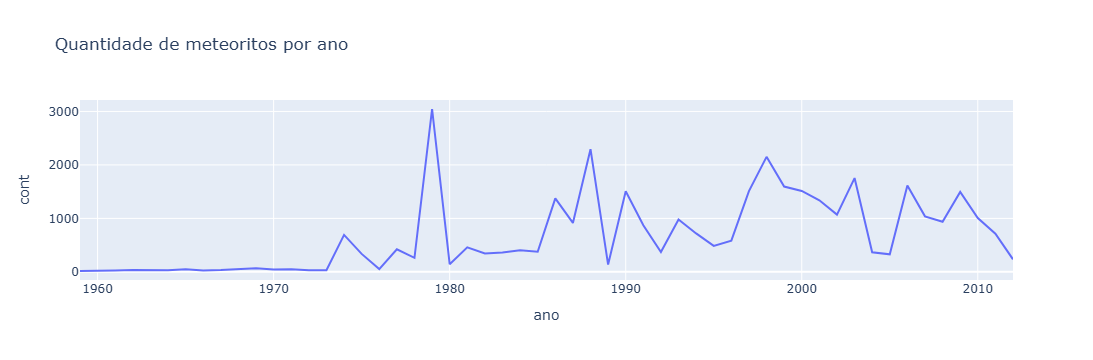

In [8]:
met_year = meteoritos['year'].value_counts()
met_year = pd.DataFrame({'ano': met_year.index, 'cont': met_year.values}).sort_values(by='ano')
px.line(met_year, x='ano', y='cont', title='Quantidade de meteoritos por ano')

### Gráfico de barras

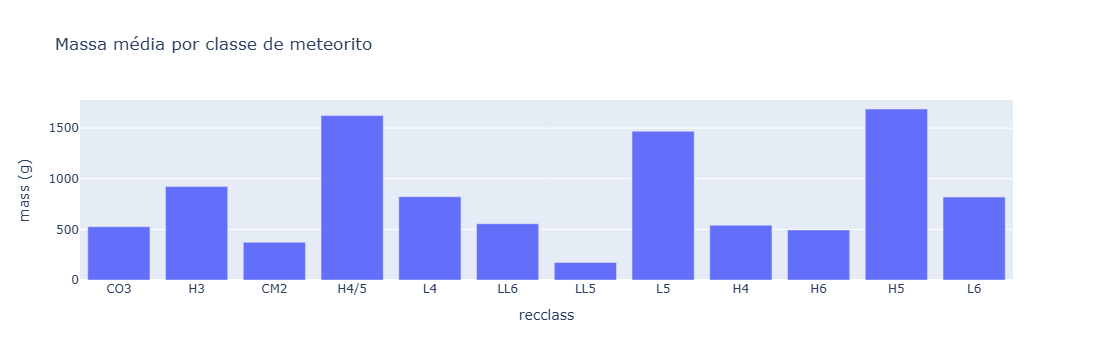

In [9]:
met_cat = meteoritos.groupby('recclass').agg({'mass (g)': 'mean', 'id': 'count'}).reset_index()
met_cat = met_cat[met_cat['id'] > 300]
met_cat = met_cat.sort_values(by='id')
px.bar(met_cat, x='recclass', y='mass (g)', title='Massa média por classe de meteorito')

## Gráfico de dispersão

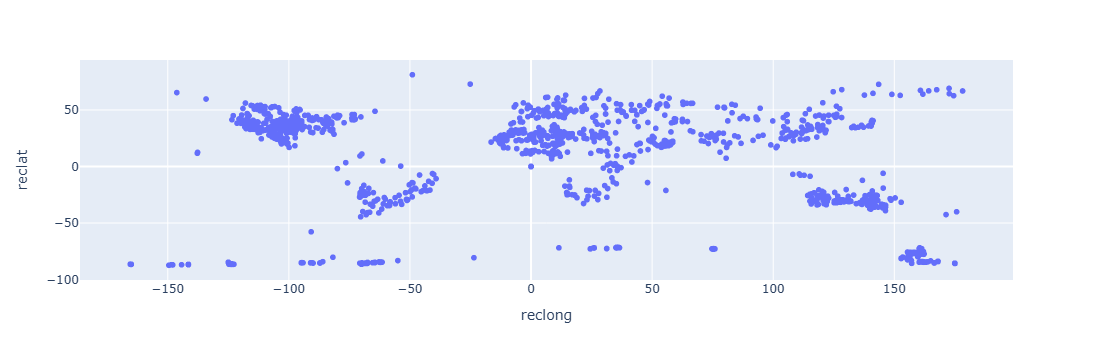

In [10]:
px.scatter(meteoritos, x='reclong', y='reclat')

### Variação com desenho de mapa

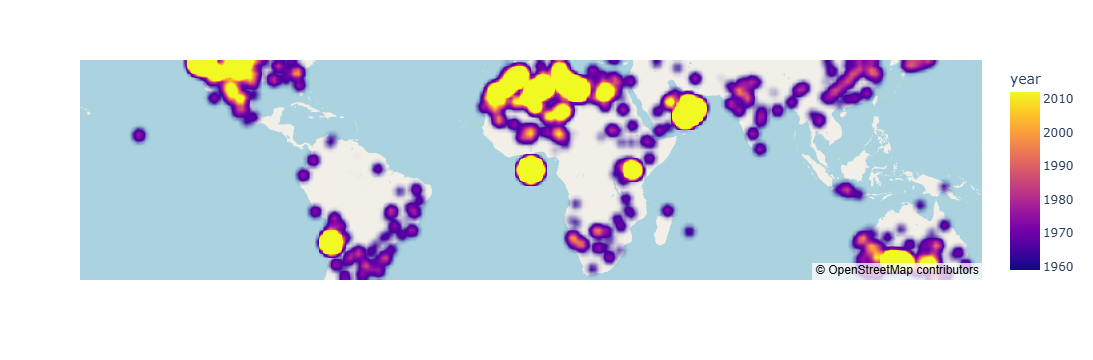

In [12]:
px.density_map(
    meteoritos, lat='reclat', lon='reclong',
    z='year', radius=10,
    center=dict(lat=0, lon=0), zoom=1,
    map_style="open-street-map"
)

In [2]:
import plotly.express as px

print([f for f in dir(px) if "density" in f])

['density_contour', 'density_heatmap', 'density_map']


## Histograma

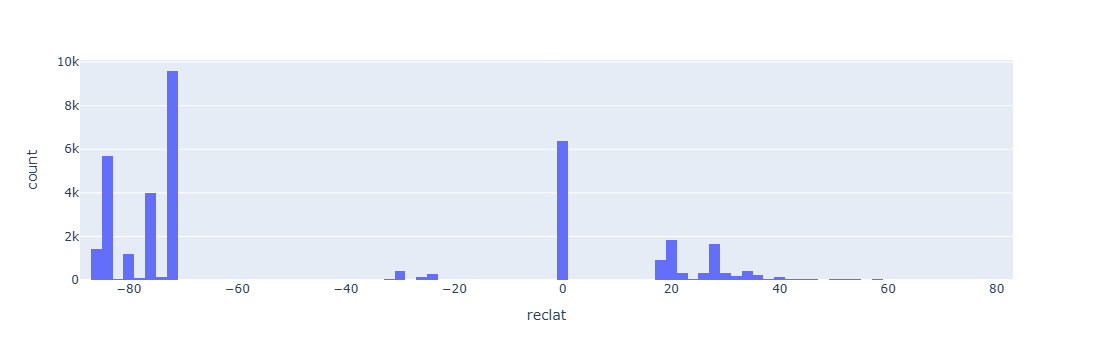

In [13]:
px.histogram(meteoritos, x="reclat", nbins=100)

### Variando número de bins

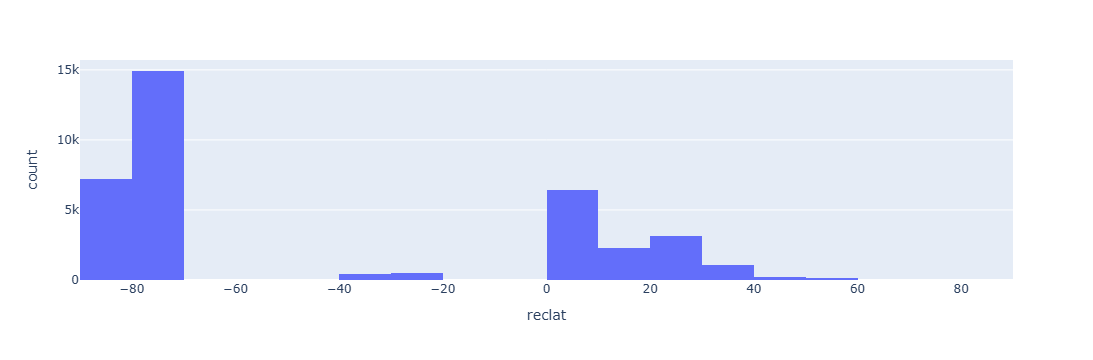

In [14]:
px.histogram (meteoritos, x="reclat", nbins=25)

## Boxplot

In [16]:
sentimentos_us = sentimentos[sentimentos["Country"] == "USA"]

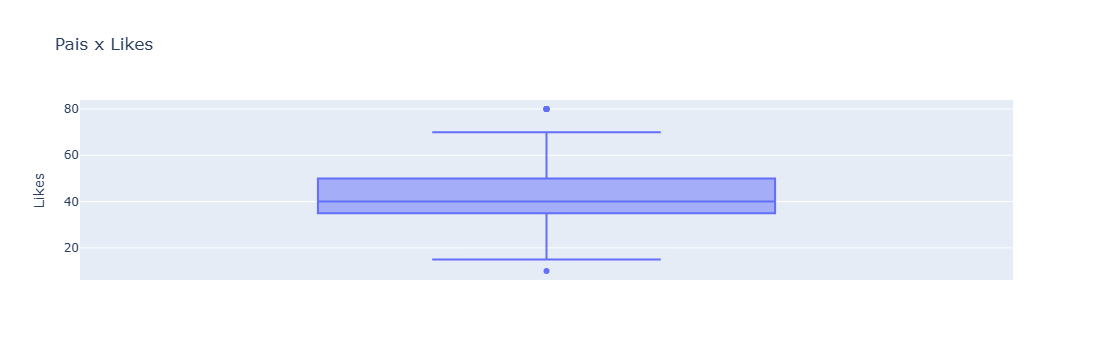

In [17]:
px.box(sentimentos_us, y='Likes', title='Pais x Likes')